In [7]:
# Import libraries
import xarray as xr
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

## Read Chla Cube

In [3]:
# Open chla dataset
chla_ds = xr.open_dataset('data/chla_slc_clip_2326.nc')

# --
chla_ds

<xarray.Dataset> Size: 2GB
Dimensions:      (time: 194, y: 1074, x: 628)
Coordinates:
  * time         (time) datetime64[ns] 2kB 2023-02-06T14:31:21.521000 ... 202...
  * y            (y) float64 9kB 6.534e+06 6.534e+06 ... 6.523e+06 6.523e+06
  * x            (x) float64 5kB 3.575e+05 3.575e+05 ... 3.638e+05 3.638e+05
Data variables:
    spatial_ref  int64 8B ...
    chla         (time, y, x) float64 1GB ...
    slc          (time, y, x) float32 523MB ...

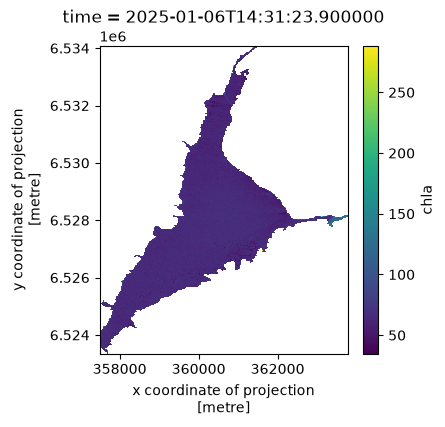

In [4]:
# Plot example
chla_ds.isel(time=120)['chla'].plot(figsize=(4, 4))

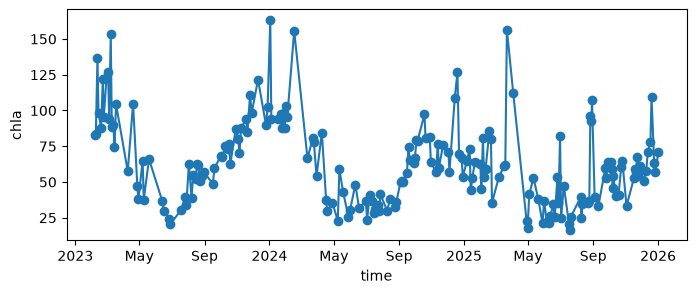

In [10]:
# --
fig, ax = plt.subplots(figsize=(8, 3))
ts_whole_mean = chla_ds['chla'].mean(dim=['x', 'y'], skipna=True)
ts_whole_mean.plot( ax=ax, marker='o', linestyle='-')

## K-means analysis

In [11]:
# GET SST VALUES AS A MATRIX
X = chla_ds['chla'].values

In [12]:
# Store chla values in a 3d numpy array
X = chla_ds['chla'].values

# X shape: (time, x, y) = (194, 1074, 628)
T, NX, NY = X.shape

# DATA RESHAPING -> (pixels, time)
X_resh = X.reshape(T, NX * NY).T.astype(np.float32)   # (674472, 194)

# MASK NAN VALUES (drop pixels with any NaN instead of filling with a fake value)
valid = ~np.isnan(X_resh).any(axis=1)
X_valid = X_resh[valid]

# DATA SCALING (each time step scaled across all pixels)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_valid)

# KMEANS
n_clusters = 5
kmeans = KMeans(n_clusters=n_clusters, n_init=10, random_state=0)
labels_valid = kmeans.fit_predict(X_scaled)

# REBUILD THE MAP (NaN where the pixel was invalid)
labels = np.full(NX * NY, np.nan, dtype=np.float32)
labels[valid] = labels_valid
label_map = labels.reshape(NX, NY)

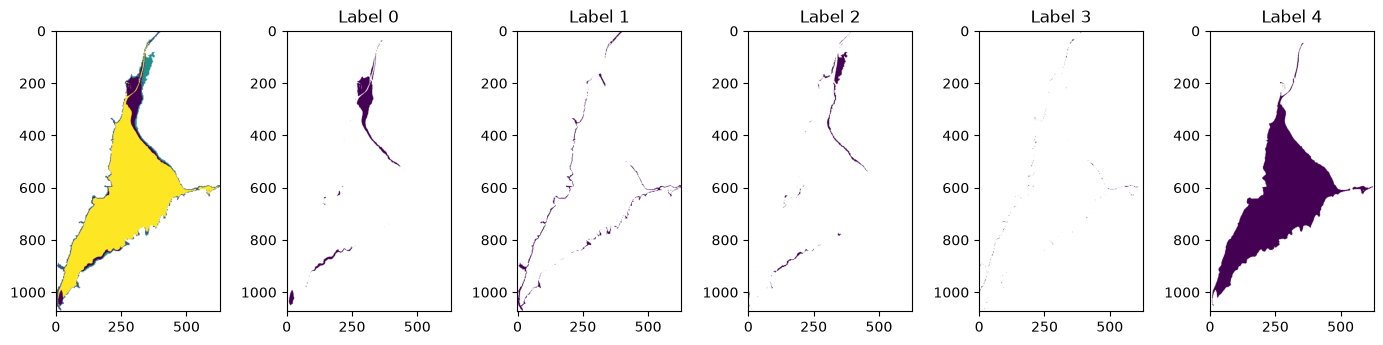

In [16]:
# --
fig, ax = plt.subplots(1, 6,figsize=(14, 6), tight_layout=True)
ax = ax.flatten()

# --
ax[0].imshow(label_map)

# --
for idx, l in enumerate(np.unique(labels)[:-1]):
    #print(l)
    ax[idx+1].imshow(np.where(label_map == l, label_map, np.nan))
    ax[idx+1].set_title(f'Label {int(l)}')

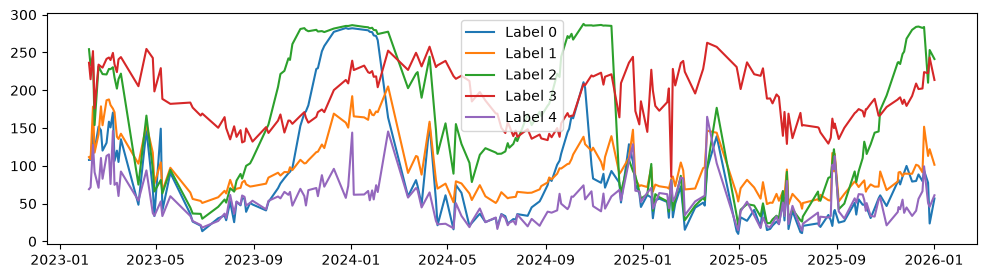

In [19]:
# --
chla_da = chla_ds['chla']

# --
labels_anls = np.unique(label_map)[:-1] #[0, 6, 7, 8, 9]

# --
fig, ax = plt.subplots(figsize=(12, 3))

# --
for idx, l in enumerate(labels_anls):
    #print(l)
    data_label = np.where(label_map == l, chla_da, np.nan)
    data_label_mean = np.nanmean(data_label, axis=(1, 2))
    
    ax.plot(chla_ds.time.values, data_label_mean, label=f'Label {int(l)}')

# --
ax.legend(loc='best', fontsize=10)

In [20]:
# --
df = pd.DataFrame()

for idx, l in enumerate(labels_anls):
    #print(l)
    data_label = np.where(label_map == l, chla_da, np.nan)
    data_label_mean = np.nanmean(data_label, axis=(1, 2))
    df[f'Lb-{l}'] = data_label_mean

corr = df.corr(method='pearson')   # or 'pearson'
print(corr)

          Lb-0.0    Lb-1.0    Lb-2.0    Lb-3.0    Lb-4.0
Lb-0.0  1.000000  0.817548  0.741162  0.314584  0.526467
Lb-1.0  0.817548  1.000000  0.696513  0.591588  0.771746
Lb-2.0  0.741162  0.696513  1.000000  0.259838  0.378433
Lb-3.0  0.314584  0.591588  0.259838  1.000000  0.389095
Lb-4.0  0.526467  0.771746  0.378433  0.389095  1.000000


In [40]:
# -
labels_sel = [0, 1, 4]

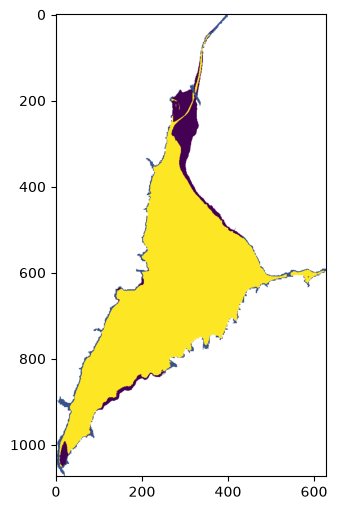

In [ ]:
# --
fig, ax = plt.subplots(figsize=(14, 6))

ax.imshow(np.where((label_map == 0) | (label_map == 1) | (label_map == 4), label_map, np.nan))

In [46]:
chla_da.x.values

array([357495., 357505., 357515., 357525., 357535., 357545., 357555.,
       357565., 357575., 357585., 357595., 357605., 357615., 357625.,
       357635., 357645., 357655., 357665., 357675., 357685., 357695.,
       357705., 357715., 357725., 357735., 357745., 357755., 357765.,
       357775., 357785., 357795., 357805., 357815., 357825., 357835.,
       357845., 357855., 357865., 357875., 357885., 357895., 357905.,
       357915., 357925., 357935., 357945., 357955., 357965., 357975.,
       357985., 357995., 358005., 358015., 358025., 358035., 358045.,
       358055., 358065., 358075., 358085., 358095., 358105., 358115.,
       358125., 358135., 358145., 358155., 358165., 358175., 358185.,
       358195., 358205., 358215., 358225., 358235., 358245., 358255.,
       358265., 358275., 358285., 358295., 358305., 358315., 358325.,
       358335., 358345., 358355., 358365., 358375., 358385., 358395.,
       358405., 358415., 358425., 358435., 358445., 358455., 358465.,
       358475., 3584

In [51]:
# --

# --
mask_array = np.where((label_map == 0) | (label_map == 1) | (label_map == 4), 1, np.nan)

# --
mask_da = xr.DataArray(
    mask_array, coords=[chla_da.y.values, chla_da.x.values], dims=['y', 'x']
)
#temp_da_coord




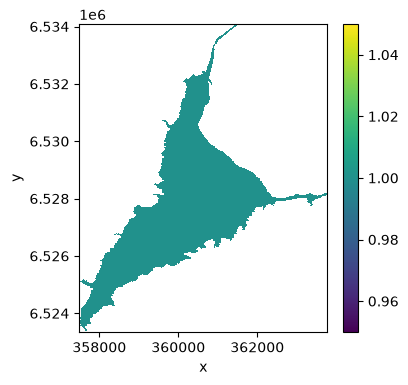

In [ ]:
# --
mask_da.plot(figsize=(4, 4))

In [ ]:
# --
mask_da.to_netcdf('output/esr_mask.nc')